In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 


x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

# Defining Model

In [4]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

In [5]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [6]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [7]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
...,...,...,...,...,...,...,...
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624


# Fit Model

In [8]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [9]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)


In [10]:
predictions_class_train = classifier.predict(x_train)
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev)


In [11]:
print(predictions_class_dev)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [12]:
print(pullforces_dev)

[5967.  2960.3 6042.8 2976.3 6097.2 2976.3 6097.2 3018.1 3423.9 3170.5
 3245.7 3237.3 3254.1 3304.7 3195.5 3245.7 3153.9 3203.8 3087.8 3330.1
 3245.7 3270.9 3162.2 3187.1 3220.5 3220.5 3145.6 3187.1 3129.  3162.2
 3096.  3112.5 3220.5 3228.9 3096.  3254.1 3270.9 3137.3 3170.5 3212.2
 3137.3 3254.1 3228.9 3145.6 3212.2 3220.5 3254.1 3262.5 3145.6 3071.3
 3055.  3038.6 3178.8 3129.  3162.2 3145.6 3170.5 3120.8 3162.2 3178.8
 3153.9 3104.3 3137.3 3153.9 3129.  3137.3 3096.  3055.  3079.6 3137.3
 3104.3 3220.5 3162.2 3178.8 3112.5 3104.3 3137.3 3104.3 3129.  3187.1
 3212.2 3145.6 3195.5 3170.5 3170.5 3112.5 3120.8 3162.2 3153.9 3170.5
 3038.6 3112.5 3153.9 3071.3 3153.9 3145.6 3170.5 3112.5 3153.9]


In [13]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_train_delta =  pullforces_train - y_train_Regressor

y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_delta = pullforces_dev - y_dev_Regressor


In [14]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
11    3816.0
12    1832.5
15    5634.8
17    2685.9
Name: PullTest (N), dtype: float64

In [15]:
pullforces_train

array([2953.9, 5988.6, 2928.2, 3014.9, 6097.2, 2979.5, 6064.5, 2937.8,
       6108.1, 3005.2, 2969.9, 2969.9, 2979.5, 6162.7, 6283.7, 6305.8,
       2966.7, 3195.5, 3270.9, 3279.3, 3178.8, 3321.6, 3237.3, 3153.9,
       3120.8, 3203.8, 3178.8, 3195.5, 3287.8, 3228.9, 3270.9, 3245.7,
       3212.2, 3212.2, 3212.2, 3212.2, 3120.8, 3279.3, 3096. , 3137.3,
       3087.8, 3153.9, 3220.5, 3287.8, 3178.8, 3203.8, 3262.5, 3162.2,
       3187.1, 3145.6, 3220.5, 3145.6, 3237.3, 3162.2, 3220.5, 3245.7,
       3170.5, 3203.8, 3262.5, 3270.9, 3254.1, 3220.5, 3237.3, 3237.3,
       3237.3, 3220.5, 3338.6, 3228.9, 3304.7, 3245.7, 3178.8, 3145.6,
       3145.6, 3262.5, 3162.2, 3162.2, 3228.9, 3195.5, 3137.3, 3237.3,
       3254.1, 3245.7, 3120.8, 3087.8, 3112.5, 3104.3, 3071.3, 3104.3,
       3120.8, 3087.8, 3055. , 3087.8, 3079.6, 3245.7, 3195.5, 3162.2,
       3304.7, 3145.6, 3079.6, 3104.3, 3212.2, 3245.7, 3262.5, 3262.5,
       3212.2, 3237.3, 3195.5, 3237.3, 3220.5, 3212.2, 3212.2, 3162.2,
      

In [16]:
y_train_delta.head(10)

Sample ID
1      826.2
2      642.2
4      577.8
5      840.1
7     2199.7
9     1047.0
11    2248.5
12    1105.3
15     473.3
17     319.3
Name: PullTest (N), dtype: float64

In [17]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Fit 2nd Model

In [18]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_delta)

# Predict on the test set
predictions_class_dev = regressor.predict(x_dev)
    

final_pred = pullforces_dev + predictions_class_dev

pred_series = pd.Series(predictions_class_dev, index=x_dev.index)
pull_series = pd.Series(pullforces_dev, index=y_dev.index)

final_pred = pull_series.loc[pred_series.index] - pred_series


In [19]:
pred_series

0     1807.190063
1      829.858643
2     1795.273682
3      845.204590
4      881.713562
         ...     
94     203.049149
95     206.984940
96     203.376511
97     198.399994
98     257.196747
Length: 99, dtype: float32

In [20]:
pull_series

0     5967.0
1     2960.3
2     6042.8
3     2976.3
4     6097.2
       ...  
94    3153.9
95    3145.6
96    3170.5
97    3112.5
98    3153.9
Length: 99, dtype: float64

In [21]:
pullforces_dev

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

In [22]:
final_pred

0     4159.809937
1     2130.441357
2     4247.526318
3     2131.095410
4     5215.486438
         ...     
94    2950.850851
95    2938.615060
96    2967.123489
97    2914.100006
98    2896.703253
Length: 99, dtype: float64

In [23]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [24]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [25]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  131.54
RMSE: 225.02
R2: 0.60


# Define Model

In [39]:
#model_name_class = 'XGBoostClassifier'
model_name_class = 'RandomForestClassifier'
#model_name_class = 'TabPFNClassifier'

#model_name_reg = 'XGBoost'
model_name_reg = 'RandomForest'
#model_name_reg = 'TabPFN'


# Cross Validation


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
14          18              95                200           15      53.95   
192        235              60                400            0      92.76   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
14       2323.94             0.929             0.925  AISI 1010 carbon steel   
192      3707.10             0.628             0.634  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
14         2334.7                 2.96      Bad      DOE  
192        2616.7                 3.07      Bad      NaN  


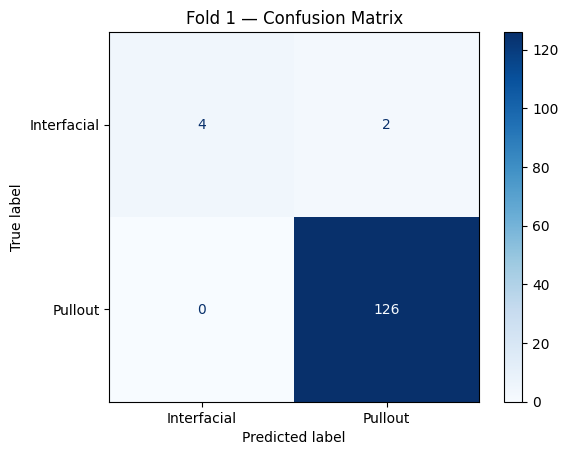

F1 Score: 0.8960629921259843
x_tr_reg: (262, 7) x_val_reg: (132, 7)
physics_train: 262 physics_val: 132
y_tr_reg: 262 y_train_delta will be: 262
dtypes: Pressure (PSI)         int64
Welding Time (ms)      int64
Angle (Deg)            int64
Force (N)            float64
Current (A)          float64
dtype: object



=== Fold 1 ===
Direct:
 MAE=168.76,
 RMSE=302.88,
 R²=0.37


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
384        480              60               1200            0      98.49   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
384      2308.35             0.624             0.626  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
384        1410.3                  1.9      Bad      NaN  


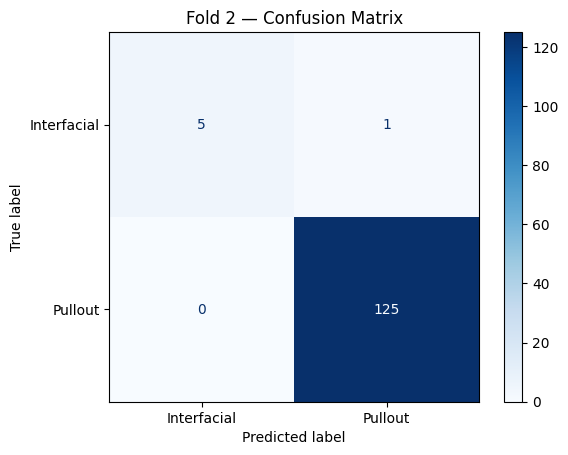

F1 Score: 0.9525534226729446
x_tr_reg: (263, 7) x_val_reg: (131, 7)
physics_train: 263 physics_val: 131
y_tr_reg: 263 y_train_delta will be: 263
dtypes: Pressure (PSI)         int64
Welding Time (ms)      int64
Angle (Deg)            int64
Force (N)            float64
Current (A)          float64
dtype: object



=== Fold 2 ===
Direct:
 MAE=142.13,
 RMSE=254.66,
 R²=0.70


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
154        189              60                400            0      91.17   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
154       3119.0              0.64             0.633  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
154        2634.6                  2.7      Bad      NaN  


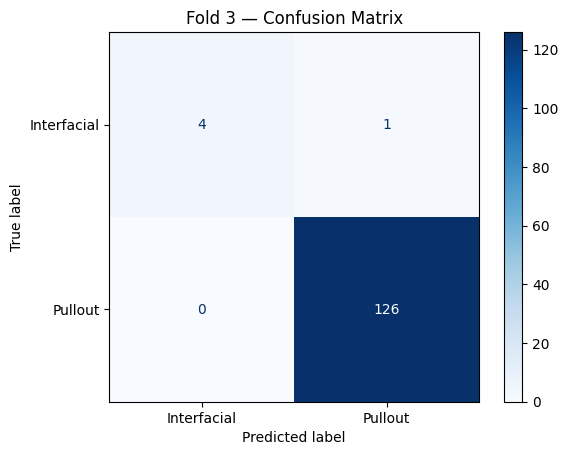

F1 Score: 0.9424681598594642
x_tr_reg: (263, 7) x_val_reg: (131, 7)
physics_train: 263 physics_val: 131
y_tr_reg: 263 y_train_delta will be: 263
dtypes: Pressure (PSI)         int64
Welding Time (ms)      int64
Angle (Deg)            int64
Force (N)            float64
Current (A)          float64
dtype: object



=== Fold 3 ===
Direct:
 MAE=136.62,
 RMSE=217.38,
 R²=0.68


=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
mean MAE:  149.17 ± 14.04
mean RMSE: 258.30 ± 35.00
mean R²:   0.58 ± 0.15


In [ ]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
}

def apply_mapping(arr):
    return np.array([mapping[x] for x in arr])

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):


    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    train_df["Category"] = apply_mapping(train_df["Category"])
    val_df["Category"] = apply_mapping(val_df["Category"])

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    # -----------------------------
    # XGBoost CLASSIFIER
    # -----------------------------
    if model_name_class == 'XGBoostClassifier':

        params = {
            "max_depth": 5,
            "learning_rate": 0.3,
            "n_estimators": 177,
            "tree_method": "hist",
            "eval_metric": "mlogloss"
        }

        # Encode labels → integers (required for XGBClassifier)
        le = LabelEncoder()
        y_val_class = le.fit_transform(y_val_class)
        y_tr_class = le.transform(y_tr_class)

        classifier = XGBClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)
        # Reverse LabelEncoder back to original class names
        preds = le.inverse_transform(preds)
        y_val_class = le.inverse_transform(y_val_class)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)


    # -----------------------------
    # RANDOM FOREST CLASSIFIER
    # -----------------------------
    elif model_name_class == 'RandomForestClassifier':

        
        params = {
            'n_estimators': 27,
            'max_depth': 7,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'log2',
        }

        classifier = RandomForestClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)

    # -----------------------------
    # TABPFN CLASSIFIER
    # -----------------------------
    elif model_name_class == 'TabPFNClassifier':

        classifier = TabPFNClassifier()
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)

    mis_idx = np.where(preds != y_val_class)[0]

    if len(mis_idx) > 0:
        mis_sample_ids = x_val_class.index[mis_idx]   # correct index space
        print("\nMisclassified rows:")
        print(cross_df[cross_df["Sample ID"].isin(mis_sample_ids)])


    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=preds,
        class_labels=["Interfacial", "Pullout"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev)


    # Train TabPFN to predict the residual (physics - true)
    y_train_delta = physics_train - y_tr_reg


    if model_name_reg == 'TabPFN':

        regressor = TabPFNRegressor()
        regressor.fit(x_tr_reg, y_train_delta)

        # Predict delta on validation, then combine with physics_val
        delta_pred = regressor.predict(x_val_reg)
        final_pred_regression_dev_without_physics = physics_val - delta_pred

        # Use the final_pred for metrics and plotting
        predictions_regression_dev_without_physics = final_pred_regression_dev_without_physics


    elif model_name_reg == 'XGBoost':

        # Convert the data into DMatrix format
        dtrain = xgb.DMatrix(x_tr_reg, label=y_train)
        dtest = xgb.DMatrix(x_val_reg, label=y_val_reg)

        # Set the parameters for the XGBoost model
        params = {
            'objective': 'reg:squarederror',
            'max_depth': 1,
            'eta': 0.57,
            'eval_metric': 'rmse',
        }

        # Train the model
        num_boost_round = 13
        bst = xgb.train(params, dtrain, num_boost_round)
        preds = bst.predict(dtest)
        
        y_train_delta = physics_train - y_train_reg 
        final_pred_regression_dev_without_physics  = physics_val - preds


    # -----------------------------
    # RANDOM FOREST REGRESSOR (delta approach)
    # -----------------------------
    elif model_name_reg == 'RandomForest':

        # Ensure physics_train/physics_val already computed and aligned
        # Compute training residual (physics - true)
        y_train_delta = physics_train - y_tr_reg

        # Sanity checks
        assert len(x_tr_reg) == len(y_tr_reg) == len(physics_train)
        assert len(x_val_reg) == len(y_val_reg) == len(physics_val)

        params = {
            'n_estimators': 19,
            'max_depth': 5,
            'min_samples_split': 6,
            'min_samples_leaf': 3,
            'random_state': 42,
        }

        rf = RandomForestRegressor(**params)
        rf.fit(x_tr_reg, y_train_delta)                       # fit on delta
        delta_pred_val = rf.predict(x_val_reg)                # predict delta on val

        # Combine physics and learned correction (same sign as TabPFN pipeline)
        final_pred_regression_dev_without_physics = physics_val - delta_pred_val

        # Use the same variable name downstream
        predictions_regression_dev_without_physics = final_pred_regression_dev_without_physics

        print("x_tr_reg:", x_tr_reg.shape, "x_val_reg:", x_val_reg.shape)
        print("physics_train:", len(physics_train), "physics_val:", len(physics_val))
        print("y_tr_reg:", len(y_tr_reg), "y_train_delta will be:", len(physics_train - y_tr_reg))
        print("dtypes:", x_tr_reg.dtypes[:5])




    direct_mae.append(mean_absolute_error(y_val_reg, predictions_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, predictions_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, predictions_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=predictions_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction ({model_name_reg}) by Category"
    )


    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")



print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"mean MAE:  {np.mean(direct_mae):.2f} ± {np.std(direct_mae):.2f}")
print(f"mean RMSE: {np.mean(direct_rmse):.2f} ± {np.std(direct_rmse):.2f}")
print(f"mean R²:   {np.mean(direct_r2):.2f} ± {np.std(direct_r2):.2f}")



# Test (TabPFN mit Explode)

In [41]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/test_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 


x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

In [42]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



In [43]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [44]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)

predictions_class_train = classifier.predict(x_train)
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev)

In [46]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_train_delta =  pullforces_train - y_train_Regressor

y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_delta = pullforces_dev - y_dev_Regressor


In [47]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_delta)

# Predict on the test set
predictions_class_dev = regressor.predict(x_dev)
    

final_pred = pullforces_dev + predictions_class_dev

pred_series = pd.Series(predictions_class_dev, index=x_dev.index)
pull_series = pd.Series(pullforces_dev, index=y_dev.index)

final_pred = pull_series.loc[pred_series.index] - pred_series


In [48]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

In [49]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  157.23
RMSE: 266.48
R2: 0.75
